
Step size h = 0.01
Coefficient matrix A =
[[ 1.    0.01]
 [-0.01  1.  ]]
Eigenvalues = [1.+0.01j 1.-0.01j]
Magnitudes  = [1.00005 1.00005]
Solution may not be Entirely Stable ;)

Step size h = 0.02
Coefficient matrix A =
[[ 1.    0.02]
 [-0.02  1.  ]]
Eigenvalues = [1.+0.02j 1.-0.02j]
Magnitudes  = [1.00019998 1.00019998]
Solution may not be Entirely Stable ;)

Step size h = 0.03
Coefficient matrix A =
[[ 1.    0.03]
 [-0.03  1.  ]]
Eigenvalues = [1.+0.03j 1.-0.03j]
Magnitudes  = [1.0004499 1.0004499]
Solution may not be Entirely Stable ;)

Step size h = 0.05
Coefficient matrix A =
[[ 1.    0.05]
 [-0.05  1.  ]]
Eigenvalues = [1.+0.05j 1.-0.05j]
Magnitudes  = [1.00124922 1.00124922]
Solution may not be Entirely Stable ;)

Step size h = 0.1
Coefficient matrix A =
[[ 1.   0.1]
 [-0.1  1. ]]
Eigenvalues = [1.+0.1j 1.-0.1j]
Magnitudes  = [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)

Step size h = 0.2
Coefficient matrix A =
[[ 1.   0.2]
 [-0.2  1. ]]
Eigenvalues = [1.+0.2

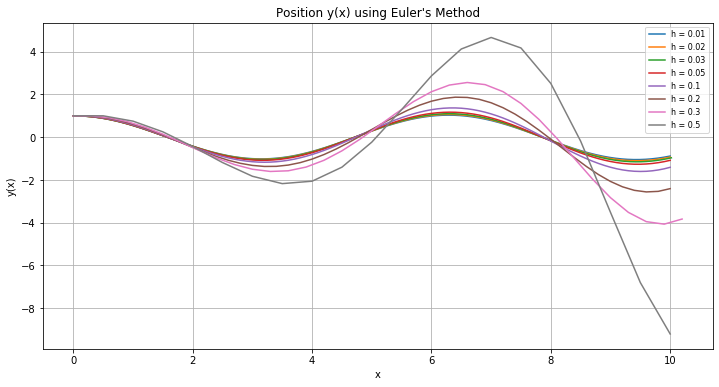

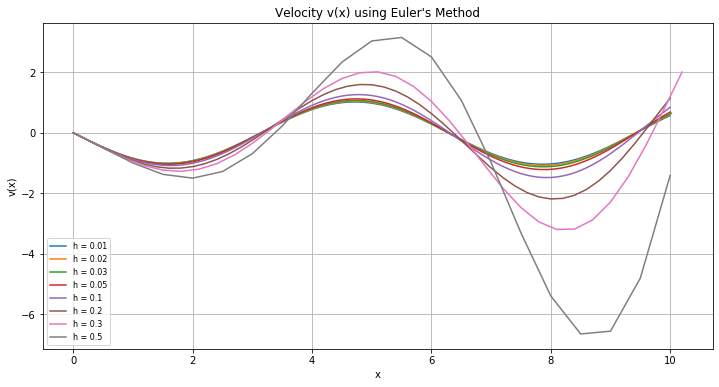

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Problem parameters
# --------------------------------------------------
k = 1.0                  # spring constant
x_start = 0.0
x_end = 10.0
y0 = 1.0                 # initial position
v0 = 0.0                 # initial velocity

step_sizes = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

# --------------------------------------------------
# Euler simulation function
# --------------------------------------------------
def euler_forward(k, h, x_start, x_end, y0, v0):
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    y_values[0] = y0
    v_values[0] = v0

    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Forward Euler updates
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n - h * k * y_n

    return x_values, y_values, v_values


plt.figure(1, figsize=(12, 6))  # Position
plt.figure(2, figsize=(12, 6))  # Velocity


for h in step_sizes:
    # Coefficient matrix for Euler's Method
    A = np.array([
        [1,   h],
        [-k*h, 1]
    ])

    # Compute eigenvalues
    eigenvalues = np.linalg.eigvals(A)
    magnitudes = np.abs(eigenvalues)

    # Print results
    print(f"\nStep size h = {h}")
    print("Coefficient matrix A =")
    print(A)
    print("Eigenvalues =", eigenvalues)
    print("Magnitudes  =", magnitudes)

    if np.all(magnitudes < 1):
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

    x, y, v = euler_forward(k, h, x_start, x_end, y0, v0)

    # Plot position
    plt.figure(1)
    plt.plot(x, y, label=f"h = {h}")

    # Plot velocity
    plt.figure(2)
    plt.plot(x, v, label=f"h = {h}")

# --------------------------------------------------
# Final plot formatting
# --------------------------------------------------
plt.figure(1)
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Position y(x) using Euler's Method")
plt.legend(fontsize=8)
plt.grid(True)

plt.figure(2)
plt.xlabel("x")
plt.ylabel("v(x)")
plt.title("Velocity v(x) using Euler's Method")
plt.legend(fontsize=8)
plt.grid(True)

plt.show()

Result matches what was found in challenge 16. The eigenvalues are close to 1, so the solutions start off looking stable but gradually gets more unstable.